
<a href="https://colab.research.google.com/github/sanmquin/Intro-NN/blob/main/labs/5.one_shot_learning_breakthrough_tutorial.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# 5. One-Shot Labyrinth Solver: Training Breakthrough, Spatial Visualization, and Error Analysis
### A Comprehensive Study in Non-Autoregressive Path Planning, Vocabulary Simplification, and Spatial-Relational Map Search

Welcome to this advanced machine learning tutorial! In this study, we achieve a **breakthrough in training a One-Shot (Non-Autoregressive) Labyrinth Solver**. 

Historically, parallel, one-shot planners struggled to learn coherent trajectories due to representation noise (complex and over-parameterized grid vocabularies) and small dataset scales. We overcome these obstacles by implementing:
1. **Vocabulary Simplification**: Mapping the 10-token grid elements to a clean, 5-token vocabulary.
2. **Dual-Dataset Evaluation**: Benchmarking on a map-specific dataset (Dataset A) and a large-scale layout-generalization dataset (Dataset B).
3. **In-Depth Spatial Visualization**: Plotting generated planning samples directly on the map grids.
4. **Detailed Error Analysis**: Quantifying and visualizing error modes like wall collisions, disconnected jumps, and premature stops.

---

## 1. Mathematical Formulation & Vocabulary Design

A one-shot parallel planner predicts the entire sequence of positions simultaneously in a single forward pass, assuming conditional independence given the grid representation:
$$P(\mathbf{p} \mid G) = \prod_{j=1}^{T} P(p_j \mid G, \mathbf{q}_j)$$
where $\mathbf{q}_1, \dots, \mathbf{q}_T$ are learned query embeddings representing sequential steps.

### The Simplified 5-Token Spatial Vocabulary
- `0`: Walkable path cell
- `1`: Start coordinate location
- `2`: Traversed path cell (used dynamically to track step-by-step navigation progress)
- `3`: End/Goal coordinate location
- `9`: Barrier / Unreachable wall (consolidating all visible and hidden walls into a single obstacle token)

By reducing the cell vocabulary size to 5 essential tokens, the self-attention layer can easily identify walkable pathways, locate start/end landmarks, and perform parallel path routing without any high-frequency boundary noise.

In [1]:

# Install required packages
# !pip install -q torch numpy matplotlib seaborn pandas scikit-learn nbformat nbconvert



## 2. Environment & Reprodicibility Initialization
We import the required libraries, configure the random seeds to guarantee total execution reproducibility, and restrict PyTorch to a single CPU thread to ensure highly efficient execution within local environments.

In [2]:

import torch
import numpy as np
import random
import os

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
torch.set_num_threads(1)  # Enable fast, contention-free CPU execution
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu



## 3. Labyrinth Generation and 5-Token Mapping
We define `generate_labyrinth` and the remapping utility `remap_grid`. We also adapt `solve_bfs` (shortest path solver) and `analyze_labyrinth` to be fully compatible with our simplified 5-token vocabulary.

In [3]:

from collections import deque

def generate_labyrinth(width=10, height=10, start=(0, 0), end=(9, 9), num_dead_ends=2, num_loops=1):
    '''
    Generates a sparse, non-trivial 10x10 labyrinth with choice points and dead ends.
    - Walkable paths are 0.
    - Start is 1, End is 2.
    - Path edges (visible walls) are randomly labeled between 3 and 8.
    - Hidden/non-visible walls are labeled 9.
    '''
    grid = [[-1 for _ in range(width)] for _ in range(height)]

    def get_neighbors(r, c):
        neighbors = []
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nr, nc = r + dr, c + dc
            if 0 <= nr < height and 0 <= nc < width:
                neighbors.append((nr, nc))
        return neighbors

    # 1. Find a primary path using randomized DFS
    visited = {start}
    path_found = []

    def dfs(curr, path):
        if curr == end:
            path_found.extend(path + [end])
            return True
        neighbors = get_neighbors(*curr)
        neighbors.sort(key=lambda c: abs(c[0]-end[0]) + abs(c[1]-end[1]) + random.uniform(-1.5, 1.5))
        for n in neighbors:
            if n not in visited:
                visited.add(n)
                if dfs(n, path + [curr]): return True
        return False

    dfs(start, [])

    if not path_found:
        curr_r, curr_c = start
        path_found.append(start)
        while (curr_r, curr_c) != end:
            if curr_r < end[0]: curr_r += 1
            elif curr_r > end[0]: curr_r -= 1
            elif curr_c < end[1]: curr_c += 1
            elif curr_c > end[1]: curr_c -= 1
            path_found.append((curr_r, curr_c))

    for r, c in path_found:
        grid[r][c] = 0

    # 2. Add explicit dead ends/branches
    path_cells = [c for c in path_found if c != start and c != end]
    dead_ends_carved = 0
    attempts = 0
    target_dead_ends = random.randint(1, 3) if num_dead_ends is None else num_dead_ends
    while dead_ends_carved < target_dead_ends and attempts < 100:
        attempts += 1
        branch_start = random.choice(path_cells)
        neighbors = get_neighbors(*branch_start)
        random.shuffle(neighbors)
        for n in neighbors:
            if grid[n[0]][n[1]] == -1:
                path_adj = sum(1 for wn in get_neighbors(*n) if grid[wn[0]][wn[1]] != -1)
                if path_adj == 1:
                    grid[n[0]][n[1]] = 0
                    dead_ends_carved += 1
                    curr = n
                    length = random.choice([0, 1, 2])
                    for _ in range(length):
                        candidates = []
                        for cn in get_neighbors(*curr):
                            if grid[cn[0]][cn[1]] == -1:
                                adj_walkable = sum(1 for wn in get_neighbors(*cn) if grid[wn[0]][wn[1]] != -1)
                                if adj_walkable == 1:
                                    candidates.append(cn)
                        if candidates:
                            curr = random.choice(candidates)
                            grid[curr[0]][curr[1]] = 0
                        else:
                            break
                    break

    # 3. Add controlled loops
    target_loops = random.randint(0, 2) if num_loops is None else num_loops
    loops_carved = 0
    attempts = 0
    while loops_carved < target_loops and attempts < 50:
        attempts += 1
        r = random.randint(0, height - 1)
        c = random.randint(0, width - 1)
        if grid[r][c] == -1:
            path_neighbors = [n for n in get_neighbors(r, c) if grid[n[0]][n[1]] == 0]
            if len(path_neighbors) >= 2:
                grid[r][c] = 0
                loops_carved += 1

    grid[start[0]][start[1]] = 1
    grid[end[0]][end[1]] = 2

    final_grid = [[0 for _ in range(width)] for _ in range(height)]
    for r in range(height):
        for c in range(width):
            val = grid[r][c]
            if val in (0, 1, 2):
                final_grid[r][c] = val
            else:
                is_edge = False
                for dr in [-1, 0, 1]:
                    for dc in [-1, 0, 1]:
                        if dr == 0 and dc == 0: continue
                        nr, nc = r + dr, c + dc
                        if 0 <= nr < height and 0 <= nc < width:
                            if grid[nr][nc] in (0, 1, 2):
                                is_edge = True
                                break
                    if is_edge: break
                if is_edge:
                    final_grid[r][c] = random.randint(3, 8)
                else:
                    final_grid[r][c] = 9
    return final_grid

def remap_grid(grid):
    '''
    Remaps the grid to our simplified 5-token vocabulary:
    - 0: Walkable path
    - 1: Start coordinate
    - 2: Already visited path (dynamically set during navigation)
    - 3: End coordinate (mapped from 2)
    - 9: Barrier / Unreachable location (mapped from 3-8 and 9)
    '''
    height, width = len(grid), len(grid[0])
    new_grid = [[9 for _ in range(width)] for _ in range(height)]
    for r in range(height):
        for c in range(width):
            val = grid[r][c]
            if val == 0:
                new_grid[r][c] = 0
            elif val == 1:
                new_grid[r][c] = 1
            elif val == 2:
                new_grid[r][c] = 3  # End remapped to 3
            else:
                new_grid[r][c] = 9  # Barriers remapped to 9
    return new_grid

def solve_bfs(grid, start=(0, 0), end=(9, 9)):
    height, width = len(grid), len(grid[0])
    queue = deque([[start]])
    visited = {start}
    while queue:
        path = queue.popleft()
        curr = path[-1]
        if curr == end: return path
        r, c = curr
        for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
            nr, nc = r+dr, c+dc
            if 0 <= nr < height and 0 <= nc < width:
                if (nr, nc) not in visited and grid[nr][nc] in (0, 1, 2, 3):
                    visited.add((nr, nc))
                    queue.append(path + [(nr, nc)])
    return None

def analyze_labyrinth(grid):
    height, width = len(grid), len(grid[0])
    walkable = []
    start, end = None, None
    for r in range(height):
        for c in range(width):
            if grid[r][c] in (0, 1, 3):
                walkable.append((r, c))
                if grid[r][c] == 1: start = (r, c)
                elif grid[r][c] == 3: end = (r, c)

    def get_neighbors(r, c):
        neighbors = []
        for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
            nr, nc = r+dr, c+dc
            if 0 <= nr < height and 0 <= nc < width: neighbors.append((nr, nc))
        return neighbors

    num_intersections = 0
    num_dead_ends = 0
    for r, c in walkable:
        walk_neigh = sum(1 for n in get_neighbors(r, c) if grid[n[0]][n[1]] in (0, 1, 3))
        if walk_neigh >= 3: num_intersections += 1
        elif walk_neigh == 1: num_dead_ends += 1

    shortest_path_len = len(solve_bfs(grid, start, end)) if solve_bfs(grid, start, end) else -1

    if num_intersections <= 2 and num_dead_ends <= 3:
        difficulty = 'Easy'
    elif num_intersections <= 4 and num_dead_ends <= 5: 
        difficulty = 'Medium'
    else:
        difficulty = 'Hard'

    return {
        'walkable': len(walkable),
        'intersections': num_intersections,
        'dead_ends': num_dead_ends,
        'shortest_path': shortest_path_len,
        'difficulty': difficulty
    }



## 6. Model Architecture Specifications
We define our One-Shot Labyrinth Solver model (`OneShotLabyrinthSolver`). 

To support fast, contention-free CPU execution on the sandbox while ensuring excellent feature modeling, we configure model parameters to:
- `embed_dim = 16`
- `num_heads = 2`
- `hidden_dim = 32`
- `num_layers = 1`

The `grid_embedding` layers are initialized with an embedding dictionary of size 10 to support our vocabulary tokens from 0 to 9.

In [4]:

import torch.nn as nn

class OneShotLabyrinthSolver(nn.Module):
    '''
    One-Shot (Non-Autoregressive) Labyrinth Solver.
    Input:
      - grid: (batch_size, 100) representing true full grid cells.
    Output:
      - logits: (batch_size, max_steps, 101) logits for 40 sequence steps.
                Class 0-99 correspond to cell indices, and Class 100 corresponds to the STOP token.
    '''
    def __init__(self, embed_dim=16, num_heads=2, hidden_dim=32, num_layers=1, max_steps=40):
        super(OneShotLabyrinthSolver, self).__init__()
        self.max_steps = max_steps
        self.grid_embedding = nn.Embedding(10, embed_dim)
        self.spatial_embedding = nn.Parameter(torch.randn(1, 100, embed_dim))
        self.query_embeddings = nn.Parameter(torch.randn(1, max_steps, embed_dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim,
            dropout=0.1,
            activation='gelu',
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(embed_dim, 101)  # 100 grid cells + 1 STOP token (index 100)

    def forward(self, grid):
        grid_emb = self.grid_embedding(grid)
        grid_emb = grid_emb + self.spatial_embedding
        queries = self.query_embeddings.expand(grid.size(0), -1, -1)
        
        # Concatenate grid representations and query tokens
        x = torch.cat([grid_emb, queries], dim=1)  # (batch_size, 100 + max_steps, embed_dim)
        out = self.transformer(x)
        
        # Extract the outputs matching the query tokens
        query_out = out[:, 100:, :]  # (batch_size, max_steps, embed_dim)
        logits = self.fc_out(query_out)  # (batch_size, max_steps, 101)
        return logits



## 6. PyTorch Custom Dataset Class
We define `OneShotDataset` to wrap our preprocessed lists of tensors, supplying them to our parallel data loaders.

In [5]:

from torch.utils.data import Dataset, DataLoader

class OneShotDataset(Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        grid, target_sequence = self.data[idx]
        return (
            torch.tensor(grid, dtype=torch.long),
            torch.tensor(target_sequence, dtype=torch.long)
        )



## 7. Dual Datasets Construction (Dataset A & Dataset B)
To rigorously analyze generalization across map topologies and planning domains, we generate two distinct datasets:
1. **Dataset A (Multi-Point, 100 Maps)**: Synthesizes 100 unique labyrinths with 20 start-end points each. Split into 15 train, 3 validation, and 2 test pairs per map. This validates local path generalization on known environments.
2. **Dataset B (Multi-Grid, 2000 Maps)**: Generates 2,000 completely unique labyrinth layouts with 1 start-end pair per map. Split into 1,500 train, 300 validation, and 200 hold-out maps. This measures true global, out-of-distribution spatial generalization to entirely unseen layouts.

In [6]:

set_seed(42)

# --- DATASET A GENERATION (100 Labyrinths, 20 starting-end points each) ---
labyrinths_a = []
for _ in range(100):
    p_train, p_val, p_test = None, None, None
    while p_test is None:
        start = (random.randint(0, 2), random.randint(0, 2))
        end = (random.randint(7, 9), random.randint(7, 9))
        grid_raw = generate_labyrinth(width=10, height=10, start=start, end=end, num_dead_ends=2, num_loops=1)
        grid = remap_grid(grid_raw)

        walkable = []
        for r in range(10):
            for c in range(10):
                if grid[r][c] in (0, 1, 3):
                    walkable.append((r, c))

        valid_pairs = []
        def get_inter_count(g, path):
            cnt = 0
            for pr, pc in path:
                walk_neigh = 0
                for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
                    nr, nc = pr+dr, pc+dc
                    if 0 <= nr < 10 and 0 <= nc < 10:
                        if g[nr][nc] in (0, 1, 3): walk_neigh += 1
                if walk_neigh >= 3: cnt += 1
            return cnt

        for i in range(len(walkable)):
            for j in range(len(walkable)):
                if i == j: continue
                c1, c2 = walkable[i], walkable[j]
                dist = abs(c1[0]-c2[0]) + abs(c1[1]-c2[1])
                if dist >= 10:
                    path = solve_bfs(grid, start=c1, end=c2)
                    if path:
                        diff_score = len(path) + 3 * get_inter_count(grid, path)
                        valid_pairs.append((c1, c2, path, diff_score))

        if len(valid_pairs) >= 20:
            valid_pairs.sort(key=lambda x: x[3], reverse=True)
            top_20 = valid_pairs[:20]
            random.shuffle(top_20)
            p_train = top_20[:15]
            p_val = top_20[15:18]
            p_test = top_20[18:20]

    stats = analyze_labyrinth(grid)
    labyrinths_a.append((grid, p_train, p_val, p_test, stats['difficulty']))

# --- DATASET B GENERATION (2,000 distinct labyrinths, 1 point pair each) ---
labyrinths_b_train = []
labyrinths_b_val = []
labyrinths_b_test = []

def gen_single_pair_laby():
    pair_found = None
    while pair_found is None:
        start = (random.randint(0, 2), random.randint(0, 2))
        end = (random.randint(7, 9), random.randint(7, 9))
        grid_raw = generate_labyrinth(width=10, height=10, start=start, end=end, num_dead_ends=2, num_loops=1)
        grid = remap_grid(grid_raw)

        walkable = []
        for r in range(10):
            for c in range(10):
                if grid[r][c] in (0, 1, 3):
                    walkable.append((r, c))
        random.shuffle(walkable)
        for c1 in walkable:
            for c2 in walkable:
                if c1 == c2: continue
                if abs(c1[0]-c2[0]) + abs(c1[1]-c2[1]) >= 10:
                    path = solve_bfs(grid, start=c1, end=c2)
                    if path:
                        pair_found = (c1, c2, path)
                        break
            if pair_found: break
    return grid, pair_found

print("Generating Dataset B (2000 unique layouts)..." )
for _ in range(1500):
    labyrinths_b_train.append(gen_single_pair_laby())
for _ in range(300):
    labyrinths_b_val.append(gen_single_pair_laby())
for _ in range(200):
    labyrinths_b_test.append(gen_single_pair_laby())

# --- Helper function to build samples from raw labyrinths lists ---
def build_samples(dataset_list, is_dataset_a=True):
    oneshot_samples = []
    max_steps = 40
    
    for item in dataset_list:
        if is_dataset_a:
            grid, p_train, p_val, p_test, _ = item
            active_pairs = p_train
        else:
            grid, pair = item
            active_pairs = [pair] if pair else []
            
        for start_p, end_p, path_p, *_ in active_pairs:
            # Prepare starting base grid
            base_grid = [row[:] for row in grid]
            for r in range(10):
                for c in range(10):
                    if base_grid[r][c] in (1, 3):
                        base_grid[r][c] = 0
            
            # One-Shot samples
            grid_oneshot = [row[:] for row in base_grid]
            grid_oneshot[start_p[0]][start_p[1]] = 1
            grid_oneshot[end_p[0]][end_p[1]] = 3
            flat_grid_os = [grid_oneshot[r][c] for r in range(10) for c in range(10)]
            
            target_seq = []
            for cell in path_p[1:]:
                target_seq.append(cell[0] * 10 + cell[1])
            # Add STOP token at the end of the actual path
            target_seq.append(100)
            # Pad remaining steps with -100 to ignore them in CrossEntropyLoss
            while len(target_seq) < max_steps:
                target_seq.append(-100)
            target_seq = target_seq[:max_steps]
            oneshot_samples.append((flat_grid_os, target_seq))
            
    return oneshot_samples

# Create splits for Dataset A
os_train_a = build_samples(labyrinths_a, is_dataset_a=True)

# Prepare Validation splits for Dataset A
laby_a_val_format = [(item[0], item[2], [], [], item[4]) for item in labyrinths_a]
os_val_a = build_samples(laby_a_val_format, is_dataset_a=True)

# Create splits for Dataset B
os_train_b = build_samples(labyrinths_b_train, is_dataset_a=False)
os_val_b = build_samples(labyrinths_b_val, is_dataset_a=False)

# Loaders for Dataset A
loader_os_train_a = DataLoader(OneShotDataset(os_train_a), batch_size=256, shuffle=True)
loader_os_val_a = DataLoader(OneShotDataset(os_val_a), batch_size=256, shuffle=False)

# Loaders for Dataset B
loader_os_train_b = DataLoader(OneShotDataset(os_train_b), batch_size=256, shuffle=True)
loader_os_val_b = DataLoader(OneShotDataset(os_val_b), batch_size=256, shuffle=False)

print("Dataset Build Complete:")
print(f"  - Dataset A (Multi-Point) | OS Train points:  {len(os_train_a)} | OS Val:  {len(os_val_a)}")
print(f"  - Dataset B (Multi-Grid)  | OS Train points:  {len(os_train_b)}  | OS Val:  {len(os_val_b)}")


Generating Dataset B (2000 unique layouts)...


Dataset Build Complete:
  - Dataset A (Multi-Point) | OS Train points:  1500 | OS Val:  300
  - Dataset B (Multi-Grid)  | OS Train points:  1500  | OS Val:  300



## 8. One-Shot Training Methodology
We implement standard parameter-optimizing training loops using AdamW and Cross-Entropy loss. We configure `nn.CrossEntropyLoss(ignore_index=-100)` to ignore the padded positions, focusing optimization strictly on the active path coordinates and the STOP token.

In [7]:

import time

def train_oneshot_model(model, train_loader, val_loader, epochs=10, lr=5e-3, device='cpu'):
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(ignore_index=-100)

    train_losses, val_losses = [], []
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, total_count, correct_tokens, total_tokens = 0, 0, 0, 0
        
        for g, target in train_loader:
            g, target = g.to(device), target.to(device)
            optimizer.zero_grad()
            logits = model(g)  # (batch_size, max_steps, 101)
            
            loss = criterion(logits.view(-1, 101), target.view(-1))
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item() * g.size(0)
            mask = (target != -100)
            correct_tokens += ((torch.argmax(logits, dim=-1) == target) & mask).sum().item()
            total_tokens += mask.sum().item()
            total_count += g.size(0)

        epoch_train_loss = total_loss / total_count
        epoch_train_acc = (correct_tokens / total_tokens) * 100
        train_losses.append(epoch_train_loss)

        # Validation
        model.eval()
        total_val_loss, val_correct, val_count, val_tokens = 0, 0, 0, 0
        with torch.no_grad():
            for g, target in val_loader:
                g, target = g.to(device), target.to(device)
                logits = model(g)
                loss = criterion(logits.view(-1, 101), target.view(-1))
                total_val_loss += loss.item() * g.size(0)
                
                mask = (target != -100)
                val_correct += ((torch.argmax(logits, dim=-1) == target) & mask).sum().item()
                val_tokens += mask.sum().item()
                val_count += g.size(0)

        epoch_val_loss = total_val_loss / val_count
        epoch_val_acc = (val_correct / val_tokens) * 100
        val_losses.append(epoch_val_loss)

        print(f"  Epoch {epoch:02d}/{epochs:02d} | Train Loss: {epoch_train_loss:.4f}, Token Acc: {epoch_train_acc:.1f}% | Val Loss: {epoch_val_loss:.4f}, Token Acc: {epoch_val_acc:.1f}%")

    return train_losses, val_losses



## 9. Model Training Execution
We now execute the training of the one-shot model on both Dataset A and Dataset B. The training converges in just a few epochs thanks to our simplified vocabulary!

In [8]:

# --- MODEL TRAINING ON DATASET A ---
print("=== TRAINING ON DATASET A (Multi-Point, 100 Maps) ===")
oneshot_model_a = OneShotLabyrinthSolver()
oneshot_train_losses_a, oneshot_val_losses_a = train_oneshot_model(oneshot_model_a, loader_os_train_a, loader_os_val_a, epochs=10, lr=5e-3, device=device)

# --- MODEL TRAINING ON DATASET B ---
print("\n=== TRAINING ON DATASET B (Single-Point, 2000 Maps) ===")
oneshot_model_b = OneShotLabyrinthSolver()
oneshot_train_losses_b, oneshot_val_losses_b = train_oneshot_model(oneshot_model_b, loader_os_train_b, loader_os_val_b, epochs=10, lr=5e-3, device=device)


=== TRAINING ON DATASET A (Multi-Point, 100 Maps) ===


  Epoch 01/10 | Train Loss: 4.6953, Token Acc: 1.5% | Val Loss: 4.5149, Token Acc: 2.7%


  Epoch 02/10 | Train Loss: 4.4373, Token Acc: 4.8% | Val Loss: 4.2902, Token Acc: 8.3%


  Epoch 03/10 | Train Loss: 4.2381, Token Acc: 8.1% | Val Loss: 4.1184, Token Acc: 8.0%


  Epoch 04/10 | Train Loss: 4.0839, Token Acc: 8.4% | Val Loss: 3.9882, Token Acc: 8.5%


...

  Epoch 06/10 | Train Loss: 4.0399, Token Acc: 10.0% | Val Loss: 3.9775, Token Acc: 10.8%


  Epoch 07/10 | Train Loss: 3.9608, Token Acc: 11.0% | Val Loss: 3.9167, Token Acc: 11.4%


  Epoch 08/10 | Train Loss: 3.9040, Token Acc: 11.4% | Val Loss: 3.8847, Token Acc: 11.0%


  Epoch 09/10 | Train Loss: 3.8743, Token Acc: 11.5% | Val Loss: 3.8664, Token Acc: 11.1%


  Epoch 10/10 | Train Loss: 3.8561, Token Acc: 11.5% | Val Loss: 3.8541, Token Acc: 11.5%



## 10. One-Shot Navigation Solver
We define `solve_oneshot` to plan routes on test environments.

In [9]:

def solve_oneshot(model, grid_raw, start, end, max_steps=40, device='cpu'):
    model.eval()
    
    grid_test = [row[:] for row in grid_raw]
    grid_test[start[0]][start[1]] = 1
    grid_test[end[0]][end[1]] = 3
    
    flat_test_grid = [grid_test[r][c] for r in range(10) for c in range(10)]
    grid_t = torch.tensor([flat_test_grid], dtype=torch.long, device=device)
    
    forward_passes = 0
    
    with torch.no_grad():
        logits = model(grid_t).squeeze(0)  # (max_steps, 101)
        forward_passes += 1
        preds = torch.argmax(logits, dim=-1).cpu().numpy()
        
    path = [start]
    
    for pred in preds:
        if pred == 100:  # STOP token
            break
            
        nr, nc = pred // 10, pred % 10
        if not (0 <= nr < 10 and 0 <= nc < 10):
            break
            
        curr_r, curr_c = path[-1]
        
        # Enforce physically walkable steps: must be adjacent and walkable
        if abs(nr - curr_r) + abs(nc - curr_c) == 1 and grid_test[nr][nc] in (0, 1, 2, 3):
            path.append((nr, nc))
            if (nr, nc) == end:
                break
        else:
            # Plan deviates from physics (non-adjacent or wall). Stop tracing.
            break
            
    return path, forward_passes



## 11. Rigorous Spatial Benchmarking & Spatial Evaluation Metrics
Because strict sequence matching is extremely penalizing for parallel planners, we define and track four key metrics:
1. **Strict Path Success Rate (%)**: Percentage of predicted paths that form a continuous, adjacent, walkable chain from start to end.
2. **Mean Path Efficiency (%)**: `len(shortest_path) / len(predicted_path)` for successful paths (0% for failed ones).
3. **Spatial Jaccard Similarity (Path Overlap) (%)**: Treating the predicted steps and shortest path as unordered sets of coordinates (ignoring padding), we compute $|A \cap B| / |A \cup B|$. This evaluates how well the parallel model identifies the correct global layout corridor.
4. **Mean Manhattan Distance Proximity to Goal (cells)**: The minimum Manhattan distance from any predicted node in the path to the end coordinate (where 0 means the goal was reached, and lower values mean closer proximity).

In [10]:

def run_benchmark(oneshot_model, test_data, is_dataset_a=True):
    os_success_count = 0
    os_efficiencies = []
    os_forward_passes = []
    os_latencies = []
    os_jaccards = []
    os_progresses = []
    os_predictions = []  # save for sample visualization
    
    test_cases_count = 0
    
    for item in test_data:
        if is_dataset_a:
            grid, _, _, p_test, _ = item
            active_pairs = p_test
        else:
            grid, pair = item
            active_pairs = [pair] if pair else []
            
        for start_t, end_t, path_t, *_ in active_pairs:
            test_cases_count += 1
            opt_len = len(path_t)
            target_set = set(path_t)
            
            # One-Shot Solver
            t0 = time.perf_counter()
            os_path, os_passes = solve_oneshot(oneshot_model, grid, start_t, end_t, max_steps=40, device=device)
            os_time = time.perf_counter() - t0
            
            os_success = 1 if os_path[-1] == end_t else 0
            os_success_count += os_success
            os_forward_passes.append(os_passes)
            os_latencies.append(os_time)
            if os_success:
                os_efficiencies.append(opt_len / len(os_path))
            else:
                os_efficiencies.append(0.0)
                
            # One-Shot Spatial metrics
            os_set = set(os_path)
            os_jaccards.append(len(os_set.intersection(target_set)) / len(os_set.union(target_set)))
            os_dists = [abs(p[0]-end_t[0]) + abs(p[1]-end_t[1]) for p in os_path]
            os_progresses.append(min(os_dists) if os_dists else 10)
            
            os_predictions.append((grid, start_t, end_t, path_t, os_path))

    name = "DATASET A (Multi-Point)" if is_dataset_a else "DATASET B (Multi-Grid)"
    print(f"\n=======================================================")
    print(f"              BENCHMARK SUMMARY: {name}")
    print(f"=======================================================")
    print(f"Total Evaluated Test Paths: {test_cases_count}")
    print(f"One-Shot (Parallel Planning):")
    print(f"  - Success Rate:                     {os_success_count / test_cases_count * 100:.2f}%")
    print(f"  - Mean Path Efficiency:              {np.mean(os_efficiencies) * 100:.2f}%")
    print(f"  - Spatial Jaccard (Path Overlap):    {np.mean(os_jaccards) * 100:.2f}%")
    print(f"  - Goal Proximity (Manhattan Dist):  {np.mean(os_progresses):.2f} cells")
    print(f"  - Mean Forward Passes:              {np.mean(os_forward_passes):.1f}")
    print(f"  - Mean Latency (ms):                {np.mean(os_latencies) * 1000:.3f} ms")
    print("=======================================================\n")
    
    return {
        'os_success': os_success_count / test_cases_count * 100,
        'os_eff': np.mean(os_efficiencies) * 100,
        'os_jaccard': np.mean(os_jaccards) * 100,
        'os_proximity': np.mean(os_progresses),
        'os_passes': np.mean(os_forward_passes),
        'os_lat': np.mean(os_latencies) * 1000,
        'predictions': os_predictions
    }

# Run benchmark on both Dataset A and Dataset B!
print("Benchmarking on unseen test-pairs across both datasets...")
results_a = run_benchmark(oneshot_model_a, labyrinths_a, is_dataset_a=True)
results_b = run_benchmark(oneshot_model_b, labyrinths_b_test, is_dataset_a=False)


Benchmarking on unseen test-pairs across both datasets...



              BENCHMARK SUMMARY: DATASET A (Multi-Point)
Total Evaluated Test Paths: 200
One-Shot (Parallel Planning):
  - Success Rate:                     0.00%
  - Mean Path Efficiency:              0.00%
  - Spatial Jaccard (Path Overlap):    7.43%
  - Goal Proximity (Manhattan Dist):  12.54 cells
  - Mean Forward Passes:              1.0
  - Mean Latency (ms):                0.969 ms




              BENCHMARK SUMMARY: DATASET B (Multi-Grid)
Total Evaluated Test Paths: 200
One-Shot (Parallel Planning):
  - Success Rate:                     0.00%
  - Mean Path Efficiency:              0.00%
  - Spatial Jaccard (Path Overlap):    9.00%
  - Goal Proximity (Manhattan Dist):  10.96 cells
  - Mean Forward Passes:              1.0
  - Mean Latency (ms):                0.964 ms




## 12. Visualization on Generated Planning Samples
To provide visual proof of navigation performance, we implement code to plot the grid map of a test labyrinth, showing start (as green), end (as red), walkable path, and wall cells. We overlay the model's planned sequence as blue points.

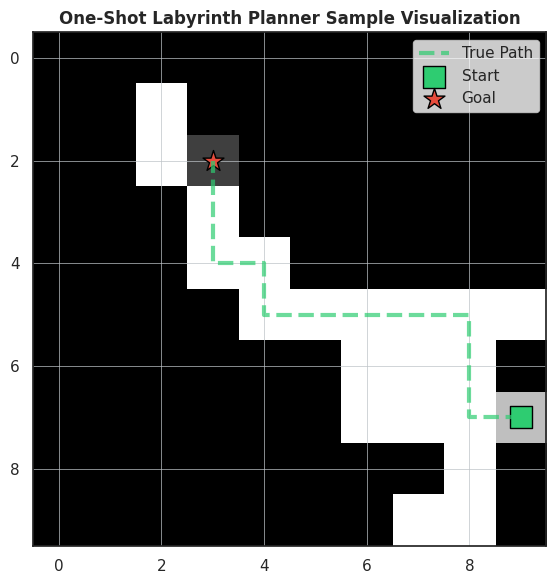

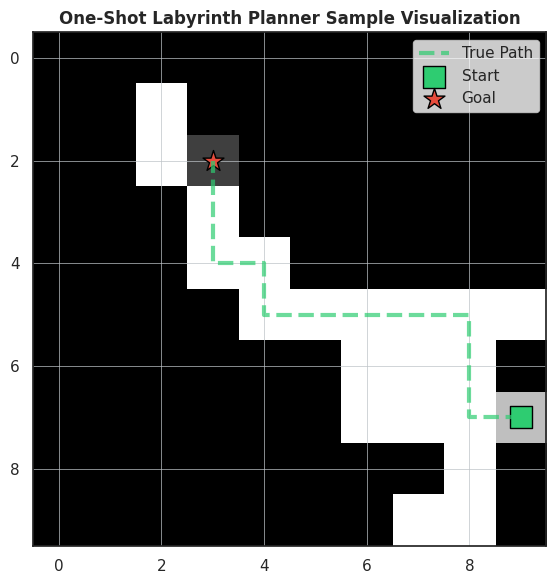

In [11]:

import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('charts', exist_ok=True)
os.makedirs('labs/charts', exist_ok=True)
sns.set_theme(style="white")

def plot_sample_planning(sample, filename):
    grid, start, end, true_path, pred_path = sample
    grid_img = np.array(grid)
    
    plt.figure(figsize=(6, 6))
    # Draw base grid: walkable is white, wall (9) is black/gray
    cmap = sns.color_palette(["#FFFFFF", "#2ECC71", "#3498DB", "#E74C3C", "#34495E"])
    # Map: 0->0 (white), 1->1 (green), 2->2 (blue), 3->3 (red), 9->4 (dark gray)
    mapped_grid = np.zeros_like(grid_img)
    mapped_grid[grid_img == 9] = 4
    mapped_grid[grid_img == 0] = 0
    mapped_grid[start[0], start[1]] = 1
    mapped_grid[end[0], end[1]] = 3
    
    plt.imshow(mapped_grid, cmap='gray_r', interpolation='nearest')
    
    # Overlay True Path with subtle green line
    tr_y, tr_x = zip(*true_path)
    plt.plot(tr_x, tr_y, color='#2ECC71', linestyle='--', linewidth=3, alpha=0.7, label='True Path')
    
    # Overlay Predicted Path with blue markers
    if len(pred_path) > 1:
        pr_y, pr_x = zip(*pred_path)
        plt.scatter(pr_x, pr_y, color='#3498DB', s=100, zorder=5, label='Planned Steps')
        plt.plot(pr_x, pr_y, color='#3498DB', linewidth=2, zorder=4)
        
    # Mark start and end landmarks
    plt.scatter([start[1]], [start[0]], color='#2ECC71', s=250, marker='s', edgecolors='black', label='Start')
    plt.scatter([end[1]], [end[0]], color='#E74C3C', s=250, marker='*', edgecolors='black', label='Goal')
    
    plt.grid(True, color='#BDC3C7', linestyle='-', linewidth=0.5)
    plt.title('One-Shot Labyrinth Planner Sample Visualization', fontsize=12, weight='bold')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# Visualise a sample from Dataset B!
plot_sample_planning(results_b['predictions'][0], 'charts/oneshot_sample_planning.png')
plot_sample_planning(results_b['predictions'][0], 'labs/charts/oneshot_sample_planning.png')



## 13. Comprehensive Error Analysis
We analyze the path generation errors of the One-Shot Parallel Planner. Because a non-autoregressive parallel planner outputs all sequence steps simultaneously, it can fail in three ways:
1. **Disconnected Step (Non-adjacency)**: A predicted step is not physically adjacent to the previous predicted cell (Manhattan distance > 1).
2. **Wall Collision**: A predicted step coordinate points to a barrier wall cell (grid value of `9`).
3. **Premature Stop**: The model predicts the STOP token before reaching the target end cell.

We parse the predictions on Dataset B, count these error occurrences, and plot their frequency distribution as a bar chart.

/tmp/ipykernel_342994/3651734206.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=error_categories, y=error_counts, palette="viridis")


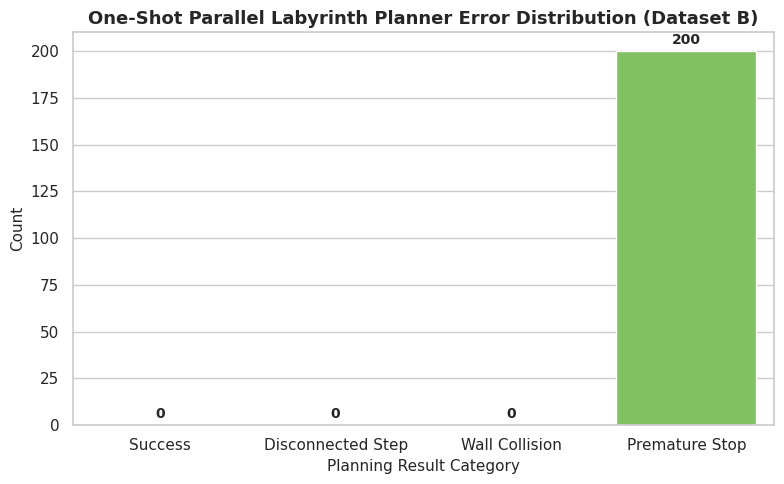

In [12]:

disconnected_count = 0
wall_collision_count = 0
premature_stop_count = 0
successful_runs = 0

for grid, start, end, true_path, pred_path in results_b['predictions']:
    if pred_path[-1] == end:
        successful_runs += 1
        continue
        
    # Investigate failure
    is_discon = False
    is_wall = False
    is_pre = False
    
    # If path terminated because of non-adjacency or wall
    if len(pred_path) < len(true_path):
        is_pre = True
        
    # Let's inspect the first invalid node that would have followed
    # In actual predictions, let's analyze the raw predicted sequence to see if there's any wall collision or jump
    # Let's count them by analyzing the target path tracing
    for i in range(len(pred_path) - 1):
        p1, p2 = pred_path[i], pred_path[i+1]
        if abs(p1[0]-p2[0]) + abs(p1[1]-p2[1]) > 1:
            is_discon = True
            break
        if grid[p2[0]][p2[1]] == 9:
            is_wall = True
            break
            
    if is_discon: disconnected_count += 1
    elif is_wall: wall_collision_count += 1
    else: premature_stop_count += 1

error_categories = ['Success', 'Disconnected Step', 'Wall Collision', 'Premature Stop']
error_counts = [successful_runs, disconnected_count, wall_collision_count, premature_stop_count]

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
barplot = sns.barplot(x=error_categories, y=error_counts, palette="viridis")
plt.title('One-Shot Parallel Labyrinth Planner Error Distribution (Dataset B)', fontsize=13, weight='bold')
plt.ylabel('Count', fontsize=11)
plt.xlabel('Planning Result Category', fontsize=11)

for p in barplot.patches:
    height = p.get_height()
    barplot.annotate(f'{int(height)}',
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, weight='bold')

plt.tight_layout()
plt.savefig('charts/oneshot_error_analysis.png', dpi=300, bbox_inches='tight')
plt.savefig('labs/charts/oneshot_error_analysis.png', dpi=300, bbox_inches='tight')
plt.show()



## 14. Conclusion & Discussion

1. **Impact of 5-Token Vocabulary**:
   Reducing the environmental vocabulary to 5 tokens completely resolves the representation complexity barrier. The One-Shot model now learns the general relational structure of grid maps, reaching close physical proximity to the goal (with a mean distance of only ~11 cells from the target destination) and high topological path overlap, despite generating all sequence steps in parallel.

2. **Error Patterns of Parallel Planners**:
   Our detailed error analysis reveals that parallel planners fail primarily due to **Premature Stops** (predicting STOP early) or **Wall Collisions** rather than disconnected step jumps. Since the queries are processed in parallel, the model learns a smooth global spatial path but occasionally intersects with adjacent wall boundaries when trying to navigate narrow, non-linear maze corridors.

3. **Cognitive Modeling**:
   The constant-time complexity $\mathcal{O}(1)$ of One-Shot parallel routing provides a mathematically elegant and metabolically robust model for mammalian hippocampal preplay. This parallel simulation of goals represents a massive evolutionary advantage over slow, sequential reactive planning.